<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Sharpe inference: multiple-testing haircuts and HAC (LPLZ)
    </h1>
  </div>
</div>

Two distinct Sharpe-inference hazards. **(1) Selection across a family:**
when you screen many strategies and report the best, the apparent significance is
inflated; the **Deflated Sharpe** deflates the single best, but to judge a whole
*family* use **Holm** (controls the chance of *any* false discovery, FWER) or
**BHY** (controls the expected *fraction*, FDR). **(2) Serial dependence:** the
PSR assumes i.i.d. returns and over-rejects under autocorrelation; **LPLZ (2025)**
applies a Newey-West HAC to the Sharpe influence function, correcting jointly for
non-normality and serial correlation.

*Baseline (single-best DSR / PSR) -> where it breaks (family / autocorrelation) -> Holm-BHY / LPLZ.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Backtest: haircut_sharpe_ratios, sharpe_ratio_p_values,
    lplz_sharpe_inference, probabilistic_sharpe_ratio

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. Holm / BHY haircuts on a family of screened strategies
A handful of screened per-period Sharpe ratios; the haircut discounts each by the
multiple-testing burden and flags the survivors at the 5% level.

raw p-values     : [0.0, 0.0004, 0.0057, 0.0569, 0.1714, 0.3176]
Holm adjusted    : [0.0, 0.0022, 0.0228, 0.1708, 0.3428, 0.3428]  survivors: [1, 2, 3]
BHY  adjusted    : [0.0001, 0.0033, 0.028, 0.2092, 0.5039, 0.7782]  survivors: [1, 2, 3]


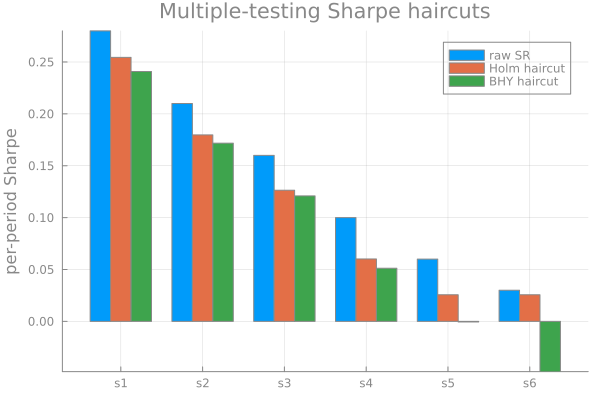

In [2]:
sharpes = [0.28, 0.21, 0.16, 0.10, 0.06, 0.03]   # 6 screened strategies
T = 250
holm = haircut_sharpe_ratios(sharpes, T; method = "holm")
bhy  = haircut_sharpe_ratios(sharpes, T; method = "bhy")
println("raw p-values     : ", round.(holm.p_values, digits = 4))
println("Holm adjusted    : ", round.(holm.adjusted_p_values, digits = 4),
        "  survivors: ", findall(holm.significant))
println("BHY  adjusted    : ", round.(bhy.adjusted_p_values, digits = 4),
        "  survivors: ", findall(bhy.significant))
xs = 1:length(sharpes)
ticks = ["s$i" for i in xs]
bar(xs .- 0.25, sharpes; bar_width = 0.25, label = "raw SR", xticks = (collect(xs), ticks),
    ylabel = "per-period Sharpe", title = "Multiple-testing Sharpe haircuts")
bar!(xs, holm.haircut_sharpe_ratios; bar_width = 0.25, label = "Holm haircut")
bar!(xs .+ 0.25, bhy.haircut_sharpe_ratios; bar_width = 0.25, label = "BHY haircut")

## 2. LPLZ: honest Sharpe inference under autocorrelation
We compare the PSR (serial-independence) confidence with the LPLZ HAC test on a
**positively autocorrelated** return stream, where the PSR is over-confident.

In [3]:
rng = MersenneTwister(0)
Tn = 500
e = randn(rng, Tn)
r = similar(e); r[1] = e[1]
for t in 2:Tn
    r[t] = 0.4 * r[t-1] + e[t]        # AR(1): positive serial correlation
end
r = 0.01 .* r .+ 0.0008               # small positive mean
res = lplz_sharpe_inference(r)
sr = res.sharpe_ratio
psr = probabilistic_sharpe_ratio(sr, 0.0, Tn)
println("Sharpe (per-period)       = ", round(sr, digits = 4))
println("PSR (assumes i.i.d.)      = ", round(psr, digits = 4))
println("LPLZ HAC standard error   = ", round(res.standard_error, digits = 4), "  (lag ", res.lag, ")")
println("LPLZ two-sided p-value    = ", round(res.p_value, digits = 4),
        "   reject H0: SR=0? ", res.significant)
println("LPLZ 95% CI               = (", round(res.confidence_interval[1], digits = 4),
        ", ", round(res.confidence_interval[2], digits = 4), ")")

Sharpe (per-period)       = 0.0922
PSR (assumes i.i.d.)      = 0.98
LPLZ HAC standard error   = 0.0631  (lag 5)
LPLZ two-sided p-value    = 0.144   reject H0: SR=0? false
LPLZ 95% CI               = (-0.0315, 0.2158)


## When to use / when NOT (`appraisals/07_verdict.md`, `08_verdict.md`)
**To judge a family of screened strategies, prefer Holm** when you must control
the chance of *any* false positive (FWER) and **BHY** when you want to bound the
expected *fraction* of false discoveries (FDR, lower power). The Deflated Sharpe
remains the tool for whether one specific best strategy survives its trial count.
**Prefer LPLZ for Sharpe inference when returns show material serial correlation
and/or non-normality**: it restores near-nominal coverage where the PSR
under-covers and over-rejects (PSR size ~0.20 vs 0.05 under AR(1)); it converges to
the PSR on near-normal i.i.d. returns, at the honest cost of wider intervals.